In [1]:
%matplotlib inline

In [210]:
import numpy as np
import warnings
warnings.filterwarnings('ignore', message='No contour levels were found')

import matplotlib as mpl
import matplotlib.pyplot as plt

plt.rc('figure', figsize=(6, 4.5))
mpl.rcParams['font.size'] = 10
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['figure.facecolor'] = 'w'
mpl.rcParams['hatch.linewidth'] = 0.5
mpl.rcParams['hatch.color'] = '0.25'

import xarray as xr

import ipywidgets as widgets
import xgcm

from numpy import pi as π

In [3]:
# trig functions that take degrees

def sind(x):
    return np.sin(np.deg2rad(x))

def cosd(x):
    return np.cos(np.deg2rad(x))

# Load datasets

## Constants

In [4]:
ρ0 = 1035 # Boussinesq reference density
g = 9.8
Ω = 7.29e-5
a = 6370e3

## Grid

MOM calls coordinates different things in different outputs. This enforces as uniform standard.

In [5]:
coord_map_h = {'lath': 'yh', 'latq': 'yq', 'lonh': 'xh', 'lonq': 'xq'}
coord_map_v = {'Interface': 'zi', 'Layer': 'zl'}

Vertical coordinates are annoyingly not in `ocean_geometry.nc`. We load them from the initial conditions and add them to the grid.

In [6]:
grid = xr.open_dataset('OUTPUT/ocean_geometry.nc').rename(coord_map_h)
ic = xr.open_dataset('OUTPUT/MOM_IC.nc').squeeze().rename({**coord_map_h, **coord_map_v})

Nx = len(grid.xh)
Ny = len(grid.yh)

grid['zi'] = ic.zi
grid['zl'] = ic.zl

grid['fh'] = 2*Ω*sind(grid.yh)
grid['fq'] = 2*Ω*sind(grid.yq)

grid['βh'] = 2*Ω*cosd(grid.yh)/a
grid['βq'] = 2*Ω*cosd(grid.yq)/a

grid['maskH'] = grid.wet
grid['maskU'] = (['yh', 'xq'], np.ones((Ny, Nx+1)))
grid['maskU'][:,[0, -1]] = 0
grid['maskV'] = (['yq', 'xh'], np.ones((Ny+1, Nx)))
grid['maskV'][[0, -1],:] = 0


grid

<xarray.Dataset>
Dimensions:  (yh: 81, xh: 60, yq: 82, xq: 61, zi: 3, zl: 2)
Coordinates:
  * yh       (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * xh       (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq       (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04
  * xq       (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 28.0 28.5 29.0 29.5 30.0
    Time     timedelta64[ns] 00:00:00
  * zi       (zi) float64 1.033e+03 1.037e+03 1.04e+03
  * zl       (zl) float64 1.035e+03 1.038e+03
Data variables: (12/26)
    geolatb  (yq, xq) float64 ...
    geolonb  (yq, xq) float64 ...
    geolat   (yh, xh) float64 ...
    geolon   (yh, xh) float64 ...
    D        (yh, xh) float64 ...
    f        (yq, xq) float64 ...
    ...       ...
    fq       (yq) float64 2.532e-05 2.655e-05 2.778e-05 ... 0.0001025 0.0001032
    βh       (yh) float64 2.252e-11 2.249e-11 2.245e-11 ... 1.632e-11 1.622e-11
    βq       (yq) float64 2.254e-11 2.251e-11 2.247e-11 ... 1.627e-11 1.617e-11
    maskH    (yh, xh) float64 ...
    maskU    (yh, xq) float64 0.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 0.0
    maskV    (yq, xh) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    filename:  ./ocean_geometry.nc

In [7]:
grid_op = xgcm.Grid(grid, periodic=False, boundary='fill', fill_value=0, coords={
    'X': {'center': 'xh', 'outer': 'xq'},
    'Y': {'center': 'yh', 'outer': 'yq'},
    'Z': {'inner': 'zl', 'outer': 'zi'},

})
grid_op

<xgcm.Grid>
X Axis (not periodic, boundary='fill'):
  * center   xh --> outer
  * outer    xq --> center
Y Axis (not periodic, boundary='fill'):
  * center   yh --> outer
  * outer    yq --> center
Z Axis (not periodic, boundary='fill'):
  * inner    zl
  * outer    zi

## Forcing

In [135]:
forcing = xr.open_dataset('INPUT/forcing.nc')

# make sure the coordinates match exactly
forcing['xh'] = grid.xh 
forcing['xq'] = grid.xq[:-1]
forcing['yh'] = grid.yh
forcing['yq'] = grid.yq[:-1]

forcing

<xarray.Dataset>
Dimensions:   (yh: 81, xh: 60, yq: 81, xq: 60)
Coordinates:
  * yh        (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * xh        (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq        (yq) float64 10.0 10.49 10.98 11.47 ... 43.61 43.97 44.33 44.68
  * xq        (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 27.5 28.0 28.5 29.0 29.5
    Time      timedelta64[ns] 00:00:00
Data variables:
    STRESS_X  (yh, xq) float64 ...
    STRESS_Y  (yq, xh) float64 ...

## Statistics

In [191]:
stats.close()

In [192]:
stats = xr.open_dataset('OUTPUT/ocean.stats.nc')
stats

<xarray.Dataset>
Dimensions:        (Layer: 2, Interface: 3, Time: 2031)
Coordinates:
  * Layer          (Layer) float64 1.035e+03 1.038e+03
  * Interface      (Interface) float64 1.033e+03 1.037e+03 1.04e+03
  * Time           (Time) timedelta64[ns] 0 days 1 days ... 2029 days 2030 days
Data variables:
    Ntrunc         (Time) float64 ...
    En             (Time) float64 ...
    APE            (Time, Interface) float64 ...
    KE             (Time, Layer) float64 ...
    H0             (Time, Interface) float64 ...
    Mass_lay       (Time, Layer) float64 ...
    Mass           (Time) float64 ...
    Mass_chg       (Time) float64 ...
    Mass_anom      (Time) float64 ...
    max_CFL_trans  (Time) float64 ...
    max_CFL_lin    (Time) float64 ...
Attributes:
    filename:  ./ocean.stats.nc

## Prognostic variables

In [193]:
prog.close()

In [194]:
prog = xr.open_mfdataset('OUTPUT/prog*.nc')
prog

<xarray.Dataset>
Dimensions:  (xq: 61, yh: 81, zl: 2, time: 60, xh: 60, yq: 82, zi: 3)
Coordinates:
  * xq       (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 28.0 28.5 29.0 29.5 30.0
  * yh       (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * zl       (zl) float64 1.035e+03 1.038e+03
  * time     (time) object 0001-02-01 00:00:00 ... 0006-01-01 00:00:00
  * xh       (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq       (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04
  * zi       (zi) float64 1.033e+03 1.037e+03 1.04e+03
Data variables:
    u        (time, zl, yh, xq) float32 dask.array<chunksize=(12, 2, 81, 61), meta=np.ndarray>
    v        (time, zl, yq, xh) float32 dask.array<chunksize=(12, 2, 82, 60), meta=np.ndarray>
    h        (time, zl, yh, xh) float64 dask.array<chunksize=(12, 2, 81, 60), meta=np.ndarray>
    e        (time, zi, yh, xh) float32 dask.array<chunksize=(12, 3, 81, 60), meta=np.ndarray>
Attributes:
    NumFilesInSet:  1
    title:          MOM Experiment
    grid_type:      regular
    grid_tile:      N/A

"e" is 4-dimensional. netcdf files and objects are index [n,k,j,i] for the time-, vertical-, meridional-, zonal-axes.

Let's take a quick look at the first record [n=0] of the top interface [k=0]. 

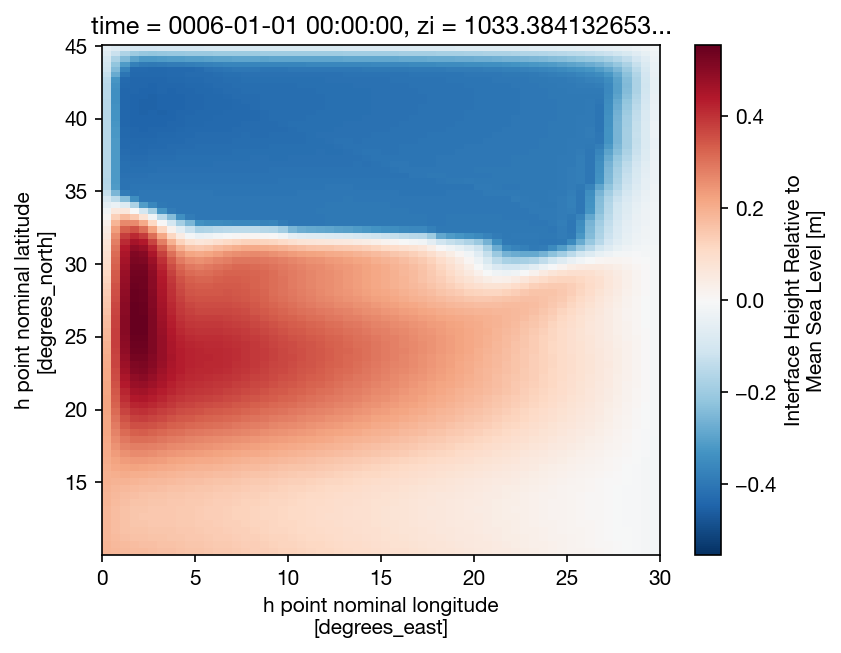

In [195]:
pc = (prog.e.isel(time=-1, zi=0)).plot()

# Plot

## Statistics

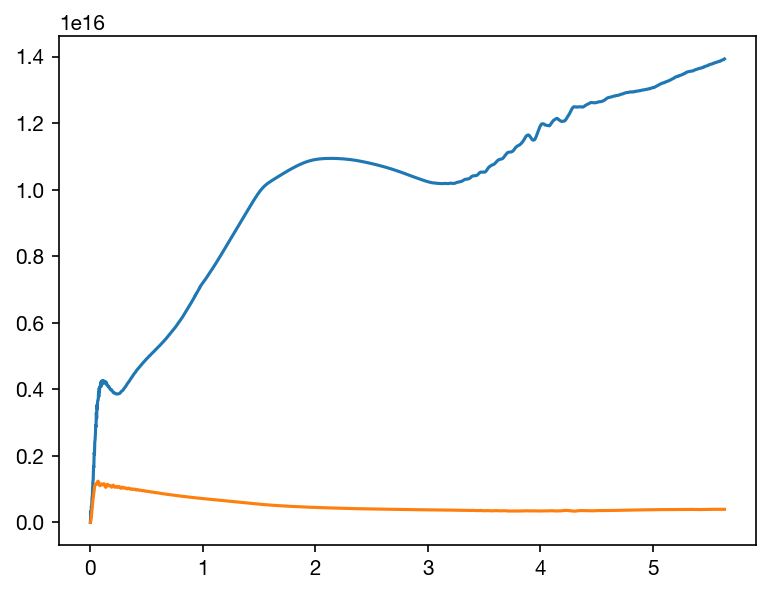

In [196]:
years = stats.Time.values.astype('timedelta64[D]').astype(float)/360

plt.plot(years, stats.KE)

## SSH

In [197]:
fld = prog.e.isel(zi=0)

vmax = float(np.abs(fld).max())
vmin = -vmax
levels = np.linspace(vmin, vmax, 31)

def plot_ssh(record, step):
    plt.contourf(fld.xh, fld.yh, fld.isel(time=record), levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
    plt.colorbar()
    plt.show()

NT = len(prog.time)
play = widgets.Play(interval=500, value=0, min=0, max=NT-1, step=1, disabled=False)
slider = widgets.IntSlider(min=0, max=NT-1)
widgets.jslink((play, 'value'), (slider, 'value'))
# widgets.HBox([play, slider])
interactive_plot = widgets.interactive(plot_ssh, record=play, step=slider)
output = interactive_plot.children[-1]
output.layout.height = '573px'
interactive_plot

interactive(children=(Play(value=0, description='record', interval=500, max=59), IntSlider(value=0, descriptio…

## Interface depth

In [198]:
fld = prog.e.isel(zi=1)

vmax = float(fld.max())
vmin = float(fld.min())
levels = np.linspace(vmin, vmax, 31)

def plot_ssh(record, step):
    plt.contourf(fld.xh, fld.yh, fld.isel(time=record), levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
    plt.colorbar()
    plt.show()

NT = len(prog.time)
play = widgets.Play(interval=500, value=0, min=0, max=NT-1, step=1, disabled=False)
slider = widgets.IntSlider(min=0, max=NT-1)
widgets.jslink((play, 'value'), (slider, 'value'))
# widgets.HBox([play, slider])
interactive_plot = widgets.interactive(plot_ssh, record=play, step=slider)
output = interactive_plot.children[-1]
output.layout.height = '573px'
interactive_plot

interactive(children=(Play(value=0, description='record', interval=500, max=59), IntSlider(value=0, descriptio…

(-10.0, 1.0)

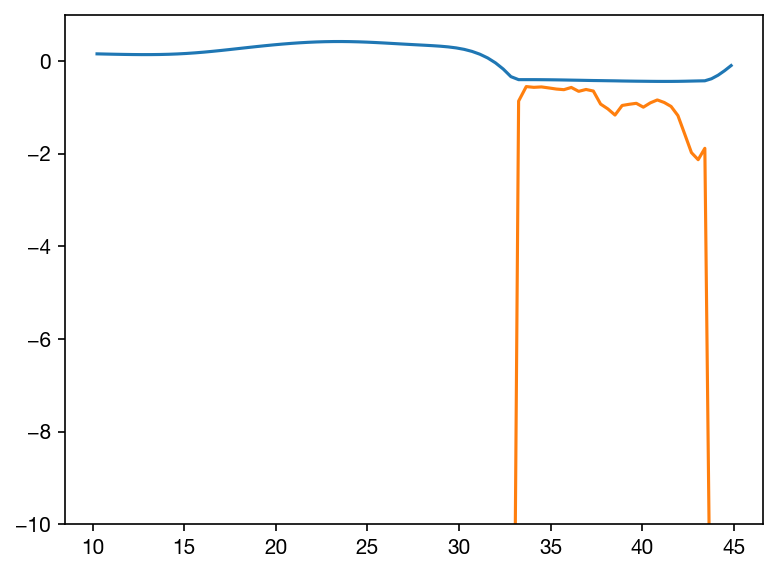

In [199]:
time = -1

plt.plot(grid.yh, prog.e.isel(zi=0, time=time).sel(xh=5, method='nearest'))
plt.plot(grid.yh, prog.e.isel(zi=1, time=time).sel(xh=5, method='nearest'))

plt.ylim([-10, 1])

## Plot thickness

In [203]:
fld = prog.h.isel(zl=0) - 0*ic.h.isel(zl=0)

# vmax = float(fld.max())
# vmin = float(fld.min())
# levels = np.linspace(vmin, vmax, 31)
vmin = 0
vmax = 25
def plot_ssh(record, step):
    
    plt.pcolormesh(fld.xh, fld.yh, fld.isel(time=record), vmin=vmin, vmax=vmax, shading='auto',)
    plt.colorbar()
    plt.show()

NT = len(prog.time)
play = widgets.Play(interval=500, value=0, min=0, max=NT-1, step=1, disabled=False)
slider = widgets.IntSlider(min=0, max=NT-1)
widgets.jslink((play, 'value'), (slider, 'value'))
# widgets.HBox([play, slider])
interactive_plot = widgets.interactive(plot_ssh, record=play, step=slider)
output = interactive_plot.children[-1]
output.layout.height = '573px'
interactive_plot

interactive(children=(Play(value=0, description='record', interval=500, max=59), IntSlider(value=0, descriptio…

Text(0.5, 1.0, 'layer 1 thickness')

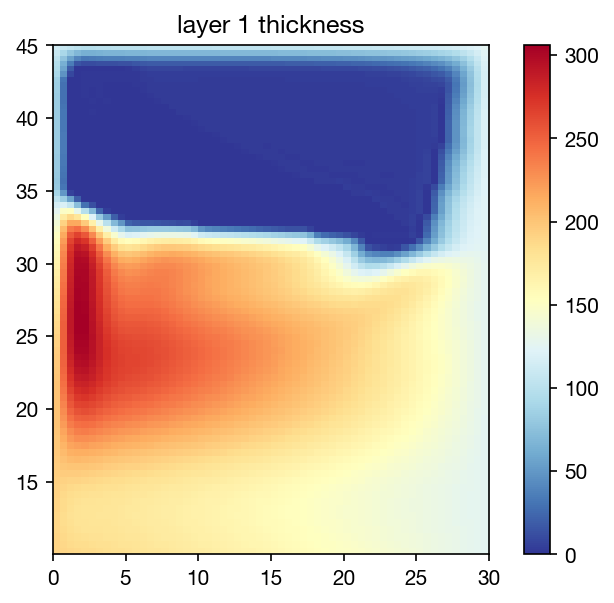

In [201]:
fig, ax = plt.subplots()

pc = ax.pcolormesh(grid.xh, grid.yh, prog.h.isel(zl=0, time=-1), vmin=0, shading='auto')
ax.set_aspect(1)
fig.colorbar(pc)

ax.set_title('layer 1 thickness')

# fig.savefig('layer1.png', bbox_inches='tight')

Text(0.5, 1.0, 'layer 1 thickness')

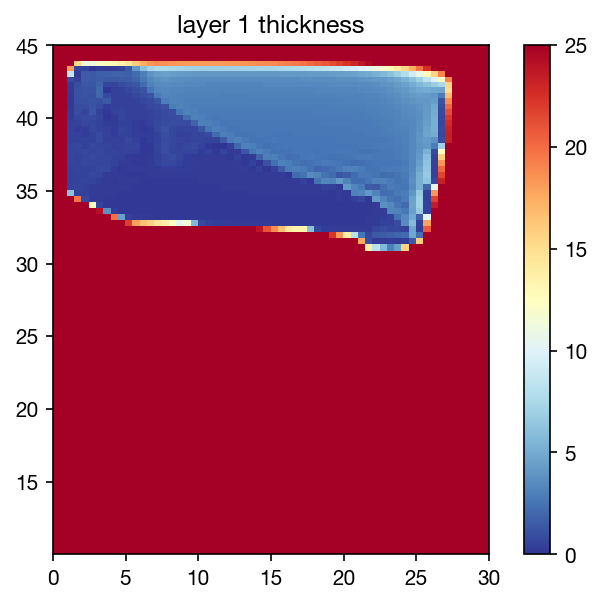

In [202]:
fig, ax = plt.subplots()

pc = ax.pcolormesh(grid.xh, grid.yh, prog.h.isel(zl=0, time=-1), vmin=0, shading='auto', vmax=25)
ax.set_aspect(1)
fig.colorbar(pc)

ax.set_title('layer 1 thickness')

# fig.savefig('layer1_zoom.png', bbox_inches='tight')

In [204]:
fld1 = prog.e.isel(zi=0).sel(xh=10, method='nearest')
fld2 = prog.e.isel(zi=1).sel(xh=10, method='nearest')

vmax = float(1)
vmin = float(-10)

def plot_ssh(record, step):    
    plt.plot(fld.yh, fld1.isel(time=record))
    plt.plot(fld.yh, fld2.isel(time=record))
    plt.ylim(vmin,vmax)
    plt.show()

NT = len(prog.time)
play = widgets.Play(interval=500, value=0, min=0, max=NT-1, step=1, disabled=False)
slider = widgets.IntSlider(min=0, max=NT-1)
widgets.jslink((play, 'value'), (slider, 'value'))
# widgets.HBox([play, slider])
interactive_plot = widgets.interactive(plot_ssh, record=play, step=slider)
output = interactive_plot.children[-1]
output.layout.height = '573px'
interactive_plot



interactive(children=(Play(value=0, description='record', interval=500, max=59), IntSlider(value=0, descriptio…

In [38]:
fld = prog.e.sel(yh=25, method='nearest').isel(zi=0)

vmax = float(fld.max())
vmin = float(fld.min())

def plot_ssh(record, step):    
    plt.plot(fld.xh, fld.isel(time=record))
    plt.ylim(vmin,vmax)
    plt.show()

NT = len(prog.time)
play = widgets.Play(interval=500, value=0, min=0, max=NT-1, step=1, disabled=False)
slider = widgets.IntSlider(min=0, max=NT-1)
widgets.jslink((play, 'value'), (slider, 'value'))
# widgets.HBox([play, slider])
interactive_plot = widgets.interactive(plot_ssh, record=play, step=slider)
output = interactive_plot.children[-1]
output.layout.height = '573px'
interactive_plot



interactive(children=(Play(value=0, description='record', interval=500, max=11), IntSlider(value=0, descriptio…

In [39]:
fld = prog.e.sel(yh=35, method='nearest').isel(zi=0)

vmax = float(fld.max())
vmin = float(fld.min())

def plot_ssh(record, step):    
    plt.plot(fld.xh, fld.isel(time=record))
    plt.ylim(vmin,vmax)
    plt.show()

NT = len(prog.time)
play = widgets.Play(interval=500, value=0, min=0, max=NT-1, step=1, disabled=False)
slider = widgets.IntSlider(min=0, max=NT-1)
widgets.jslink((play, 'value'), (slider, 'value'))
# widgets.HBox([play, slider])
interactive_plot = widgets.interactive(plot_ssh, record=play, step=slider)
output = interactive_plot.children[-1]
output.layout.height = '573px'
interactive_plot



interactive(children=(Play(value=0, description='record', interval=500, max=11), IntSlider(value=0, descriptio…

In [40]:
fld = prog.e.sel(yh=25, method='nearest').isel(zi=1)

vmax = float(fld.max())
vmin = float(fld.min())

def plot_ssh(record, step):    
    plt.plot(fld.xh, fld.isel(time=record))
    plt.plot(fld.xh, fld.isel(time=0))
    plt.ylim(vmin,vmax)
    plt.show()

NT = len(prog.time)
play = widgets.Play(interval=500, value=0, min=0, max=NT-1, step=1, disabled=False)
slider = widgets.IntSlider(min=0, max=NT-1)
widgets.jslink((play, 'value'), (slider, 'value'))
# widgets.HBox([play, slider])
interactive_plot = widgets.interactive(plot_ssh, record=play, step=slider)
output = interactive_plot.children[-1]
output.layout.height = '573px'
interactive_plot



interactive(children=(Play(value=0, description='record', interval=500, max=11), IntSlider(value=0, descriptio…

In [70]:
grid.yh

<xarray.DataArray 'yh' (yh: 81)>
array([10.246108, 10.737747, 11.228587, 11.718593, 12.207732, 12.695969,
       13.183271, 13.669604, 14.154935, 14.639231, 15.12246 , 15.604591,
       16.085591, 16.565429, 17.044075, 17.521499, 17.99767 , 18.472558,
       18.946135, 19.418373, 19.889242, 20.358716, 20.826766, 21.293367,
       21.758491, 22.222113, 22.684207, 23.144749, 23.603714, 24.061078,
       24.516817, 24.97091 , 25.423332, 25.874063, 26.323081, 26.770364,
       27.215893, 27.659647, 28.101607, 28.541754, 28.98007 , 29.416537,
       29.851137, 30.283853, 30.714669, 31.143569, 31.570538, 31.99556 ,
       32.418622, 32.83971 , 33.258809, 33.675907, 34.090992, 34.504052,
       34.915075, 35.32405 , 35.730966, 36.135814, 36.538584, 36.939267,
       37.337855, 37.734338, 38.128709, 38.520961, 38.911087, 39.299081,
       39.684936, 40.068646, 40.450208, 40.829615, 41.206863, 41.58195 ,
       41.95487 , 42.32562 , 42.694199, 43.060603, 43.42483 , 43.786879,
       44.146748, 44.504437, 44.859944])
Coordinates:
  * yh       (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
    Time     timedelta64[ns] 00:00:00
Attributes:
    long_name:       Latitude
    units:           degrees_north
    cartesian_axis:  Y

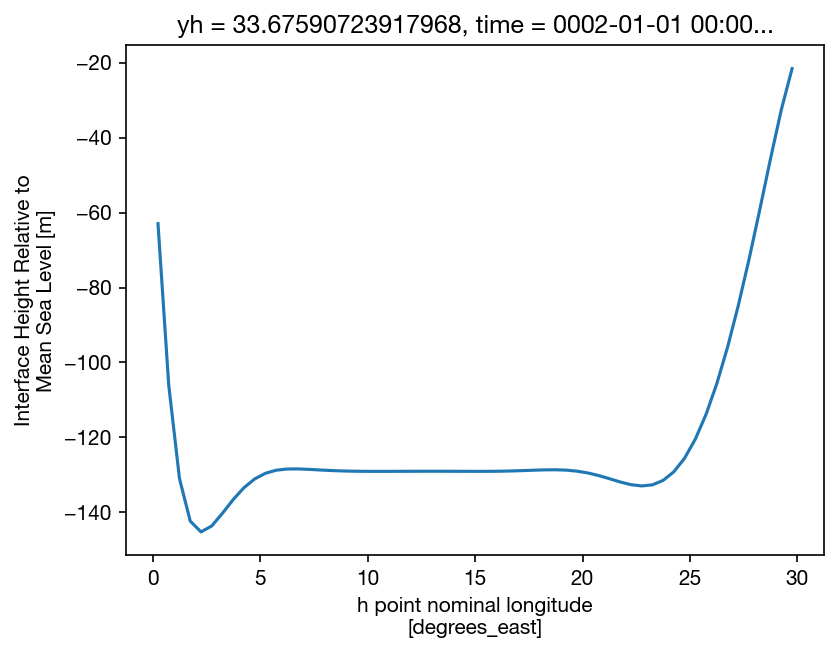

In [41]:
fld = prog.e.sel(yh=33.5, method='nearest').isel(zi=1, time=-1).plot()

In [42]:
fld = prog.e.sel(yh=35, method='nearest').isel(zi=1)

vmax = float(fld.max())
vmin = float(fld.min())

def plot_ssh(record, step):    
    plt.plot(fld.xh, fld.isel(time=record))
    plt.plot(fld.xh, fld.isel(time=0))
    plt.ylim(vmin,vmax)
    plt.show()

NT = len(prog.time)
play = widgets.Play(interval=500, value=0, min=0, max=NT-1, step=1, disabled=False)
slider = widgets.IntSlider(min=0, max=NT-1)
widgets.jslink((play, 'value'), (slider, 'value'))
# widgets.HBox([play, slider])
interactive_plot = widgets.interactive(plot_ssh, record=play, step=slider)
output = interactive_plot.children[-1]
output.layout.height = '573px'
interactive_plot



interactive(children=(Play(value=0, description='record', interval=500, max=11), IntSlider(value=0, descriptio…

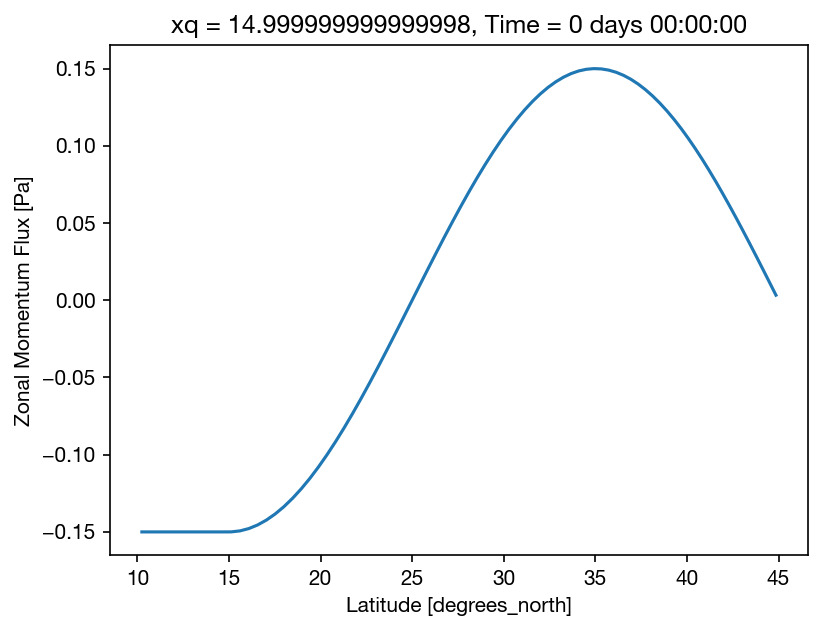

In [130]:
forcing.STRESS_X.isel(xq=30).plot()

## Barotropic streamfunction

In [211]:
cont.close()

In [212]:
cont = xr.open_mfdataset('OUTPUT/cont*.nc', decode_times=False)
cont

<xarray.Dataset>
Dimensions:     (xq: 61, yh: 81, zl: 2, time: 60, nv: 2, xh: 60, yq: 82)
Coordinates:
  * xq          (xq) float64 0.0 0.5 1.0 1.5 2.0 ... 28.0 28.5 29.0 29.5 30.0
  * yh          (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * zl          (zl) float64 1.035e+03 1.038e+03
  * time        (time) float64 15.0 45.0 75.0 ... 1.725e+03 1.755e+03 1.785e+03
  * nv          (nv) float64 1.0 2.0
  * xh          (xh) float64 0.25 0.75 1.25 1.75 ... 28.25 28.75 29.25 29.75
  * yq          (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04
Data variables:
    uh          (time, zl, yh, xq) float32 dask.array<chunksize=(12, 2, 81, 61), meta=np.ndarray>
    vh          (time, zl, yq, xh) float32 dask.array<chunksize=(12, 2, 82, 60), meta=np.ndarray>
    average_T1  (time) float64 dask.array<chunksize=(12,), meta=np.ndarray>
    average_T2  (time) float64 dask.array<chunksize=(12,), meta=np.ndarray>
    average_DT  (time) float64 dask.array<chunksize=(12,), meta=np.ndarray>
    time_bnds   (time, nv) float64 dask.array<chunksize=(12, 2), meta=np.ndarray>
Attributes:
    NumFilesInSet:  1
    title:          MOM Experiment
    grid_type:      regular
    grid_tile:      N/A

In [213]:
psiB = grid_op.cumsum(cont.vh.sum(dim='zl'), axis='X', to='outer', boundary='fill')/1e6

In [214]:
fld = psiB

vmax = float(np.abs(fld).max())
vmin = -vmax
levels = np.linspace(vmin, vmax, 31)

def plot_ssh(record, step):
    
    cs = plt.contourf(fld.xq, fld.yq, fld.isel(time=record), levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
    plt.contour(grid.xh, grid.yh, prog.e.isel(zi=1, time=record), levels=[-10], colors='k', linestyles='-')
    plt.colorbar(cs)
    plt.show()

NT = len(cont.time)
play = widgets.Play(interval=500, value=0, min=0, max=NT-1, step=1, disabled=False)
slider = widgets.IntSlider(min=0, max=NT-1)
widgets.jslink((play, 'value'), (slider, 'value'))
# widgets.HBox([play, slider])
interactive_plot = widgets.interactive(plot_ssh, record=play, step=slider)
output = interactive_plot.children[-1]
output.layout.height = '573px'
interactive_plot

interactive(children=(Play(value=0, description='record', interval=500, max=59), IntSlider(value=0, descriptio…

## Baroclinic Defomation Radius

In [169]:
gprime = float(grid.zl.diff(dim='zl')*g/ρ0)

Hbar = prog.h.isel(zl=0)*prog.h.isel(zl=1)/prog.h.sum(dim='zl') # harmonic mean of layer thicknesses

c = np.sqrt(gprime*Hbar)
Ld = np.sqrt(gprime*Hbar)/grid.fh

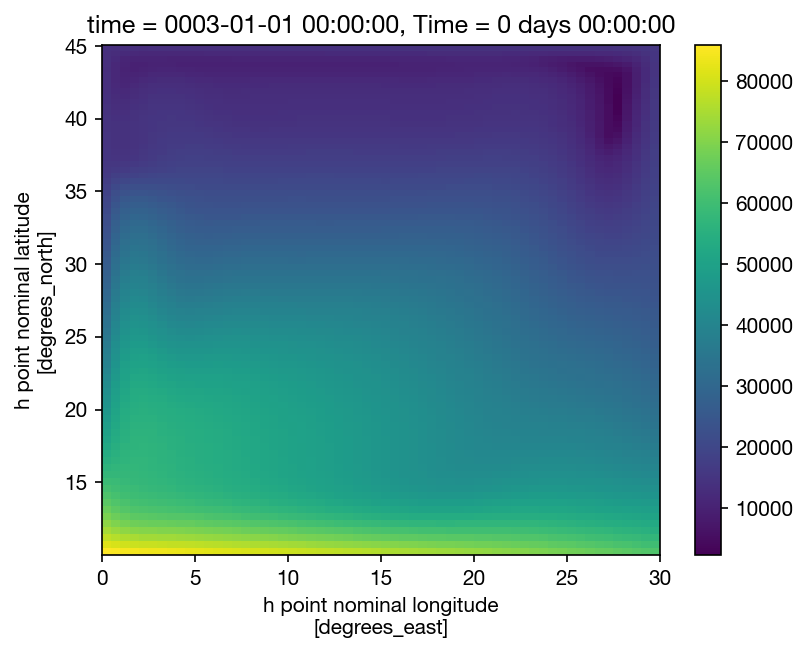

In [171]:
Ld.where(Ld>1000).isel(time=-1).plot()

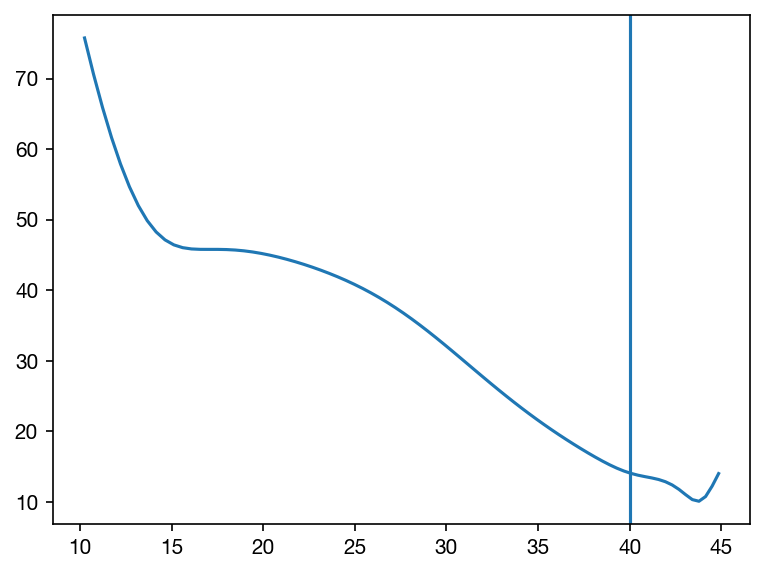

In [172]:
plt.plot(grid.yh, (Ld/1e3).isel(time=-1, xh=30))
plt.axvline(40)

### Basin crossing time

In [81]:
Lx

<xarray.DataArray (yq: 82)>
array([3284653.13152188, 3279558.45921564, 3274230.60430334,
       3268671.510793  , 3262883.19892847, 3256867.7634378 ,
       3250627.37172848, 3244164.26203238, 3237480.74150316,
       3230579.18426921, 3223462.02944496, 3216131.77910359,
       3208590.99621416, 3200842.30254618, 3192888.37654461,
       3184731.95117847, 3176375.81176593, 3167822.79377904,
       3159075.78063102, 3150137.70144927, 3141011.52883679,
       3131700.2766253 , 3122206.9976226 , 3112534.78135734,
       3102686.75182374, 3092666.06522927, 3082475.90774768,
       3072119.49328033, 3061600.06122813, 3050920.87427676,
       3040085.21619746, 3029096.3896658 , 3017957.71410074,
       3006672.52352598, 2995244.16445598, 2983675.99380837,
       2971971.37684481, 2960133.68514222, 2948166.29459589,
       2936072.58345629, 2923855.93040108, 2911519.71264382,
       2899067.30408061, 2886502.0734761 , 2873827.38268993,
       2861046.58494476, 2848163.02313681, 2835180.02818983,
       2822100.91745341, 2808928.9931461 , 2795667.54084431,
       2782319.82801722, 2768889.10260838, 2755378.59166425,
       2741791.50001004, 2728131.00897305, 2714400.27515363,
       2700602.42924394, 2686740.57489426, 2672817.78762712,
       2658837.1137988 , 2644801.56960816, 2630714.14015254,
       2616577.77853035, 2602395.40498996, 2588169.90612456,
       2573904.13411238, 2559600.90600187, 2545263.00304112,
       2530893.17005107, 2516494.11484169, 2502068.50767059,
       2487618.98074321, 2473148.12775389, 2458658.5034671 ,
       2444152.62333778, 2429632.96317033, 2415101.95881498,
       2400562.00590101, 2386015.45960568, 2371464.6344581 ,
       2356911.80417703])
Coordinates:
    Time     timedelta64[ns] 00:00:00
  * yq       (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04

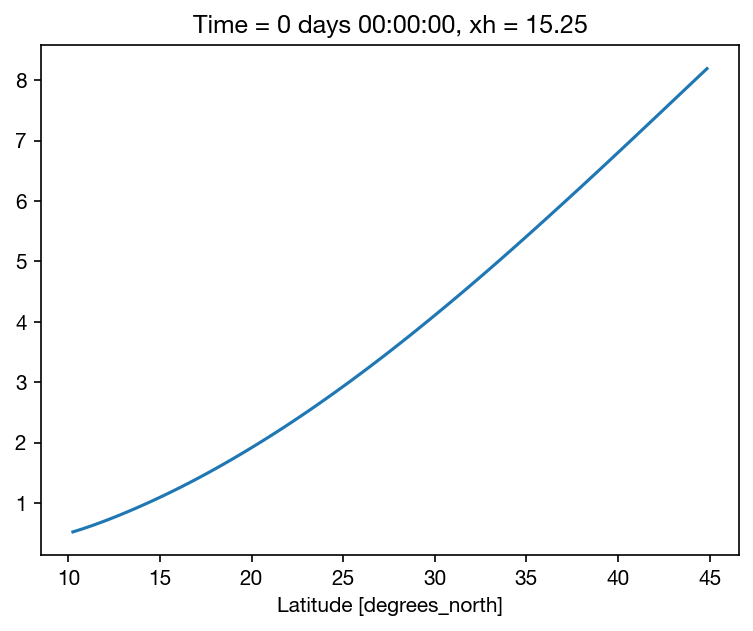

In [85]:
Lx = a*np.deg2rad(grid.xq.isel(xq=-1) - grid.xq.isel(xq=0))*cosd(grid.yh)
T = Lx/(grid.βh*Ld.isel(time=0,xh=30)**2)
(T/3600/24/365).plot()

## Geostrophic velocity in upper layer

In [80]:
grid

<xarray.Dataset>
Dimensions:  (xh: 60, xq: 61, yh: 81, yq: 82, zi: 3, zl: 2)
Coordinates:
  * yh       (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * xh       (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq       (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04
  * xq       (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 28.0 28.5 29.0 29.5 30.0
    Time     timedelta64[ns] 00:00:00
  * zi       (zi) float64 1.034e+03 1.036e+03 1.037e+03
  * zl       (zl) float64 1.035e+03 1.036e+03
Data variables: (12/23)
    geolatb  (yq, xq) float64 10.0 10.0 10.0 10.0 ... 45.04 45.04 45.04 45.04
    geolonb  (yq, xq) float64 0.0 0.5 1.0 1.5 2.0 ... 28.0 28.5 29.0 29.5 30.0
    geolat   (yh, xh) float64 10.25 10.25 10.25 10.25 ... 44.86 44.86 44.86
    geolon   (yh, xh) float64 0.25 0.75 1.25 1.75 ... 28.25 28.75 29.25 29.75
    D        (yh, xh) float64 4e+03 4e+03 4e+03 4e+03 ... 4e+03 4e+03 4e+03
    f        (yq, xq) float64 2.533e-05 2.533e-05 ... 0.0001032 0.0001032
    ...       ...
    dyCuo    (yh, xq) float64 0.0 5.477e+04 5.477e+04 ... 3.945e+04 0.0
    wet      (yh, xh) float64 1.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 1.0
    fh       (yh) float64 2.593e-05 2.716e-05 2.839e-05 ... 0.0001022 0.0001028
    fq       (yq) float64 2.532e-05 2.655e-05 2.778e-05 ... 0.0001025 0.0001032
    βh       (yh) float64 2.252e-11 2.249e-11 2.245e-11 ... 1.632e-11 1.622e-11
    βq       (yq) float64 2.254e-11 2.251e-11 2.247e-11 ... 1.627e-11 1.617e-11
Attributes:
    filename:  ./ocean_geometry.nc

In [173]:
v = prog.v.isel(time=-1, zl=0).load()
η = prog.e.isel(time=-1, zi=0).load()
ηx = grid_op.diff(η, axis='X')/grid.dxCu
vg = grid.maskV*grid_op.interp(ηx, axis=['X', 'Y'])/grid.fq
va = vg - v

hV = grid.maskV*grid_op.interp(prog.h.isel(time=-1, zl=0), axis='Y')
# vg[:,0] = 0

In [174]:
hV

<xarray.DataArray (yq: 82, xh: 60)>
dask.array<multiply, shape=(82, 60), dtype=float64, chunksize=(80, 60), chunktype=numpy.ndarray>
Coordinates:
  * xh       (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq       (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04
    Time     timedelta64[ns] 00:00:00

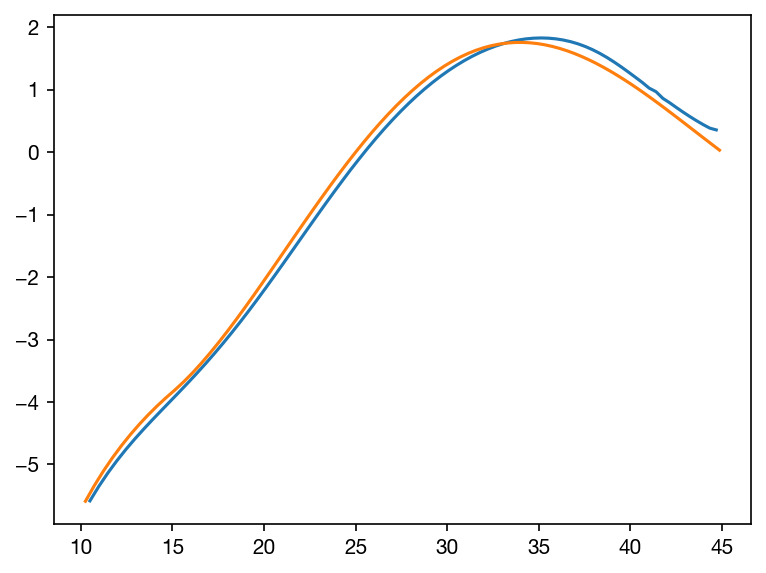

In [176]:
plt.plot(grid.yq, (hV*va).isel(xh=25))
plt.plot(grid.yh, (forcing.STRESS_X/grid.fh).isel(xq=25)/ρ0)

In [177]:
forcing_diag = xr.open_dataset('forcing__0101_006.nc')
forcing_diag

<xarray.Dataset>
Dimensions:  (time: 1, xh: 60, xq: 61, yh: 81, yq: 82)
Coordinates:
  * xq       (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 28.0 28.5 29.0 29.5 30.0
  * yh       (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * time     (time) object 0101-01-06 00:00:00
  * xh       (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq       (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04
Data variables:
    taux     (time, yh, xq) float32 ...
    tauy     (time, yq, xh) float32 ...
Attributes:
    NumFilesInSet:  1
    title:          MOM Experiment
    grid_type:      regular
    grid_tile:      N/A

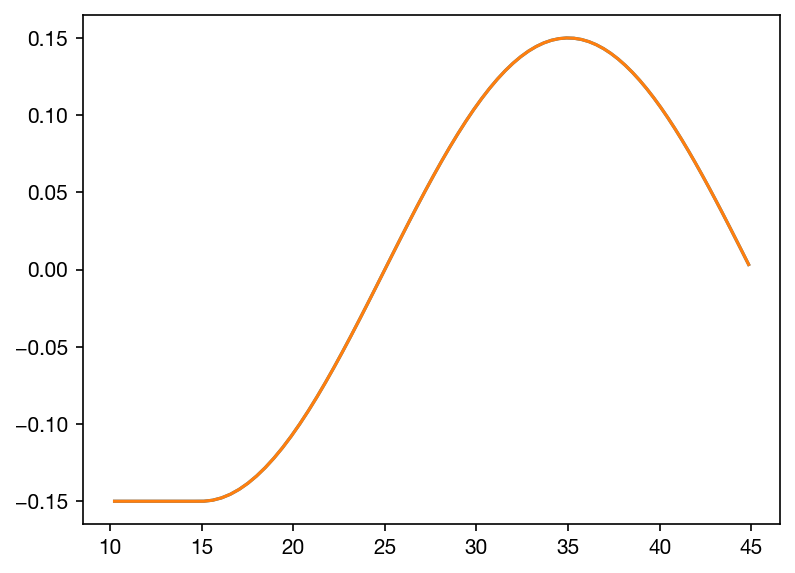

In [190]:
plt.plot(forcing.yh, forcing.STRESS_X.isel(xq=30))
plt.plot(forcing_diag.yh, forcing_diag.taux.isel(xq=30,time=-1))

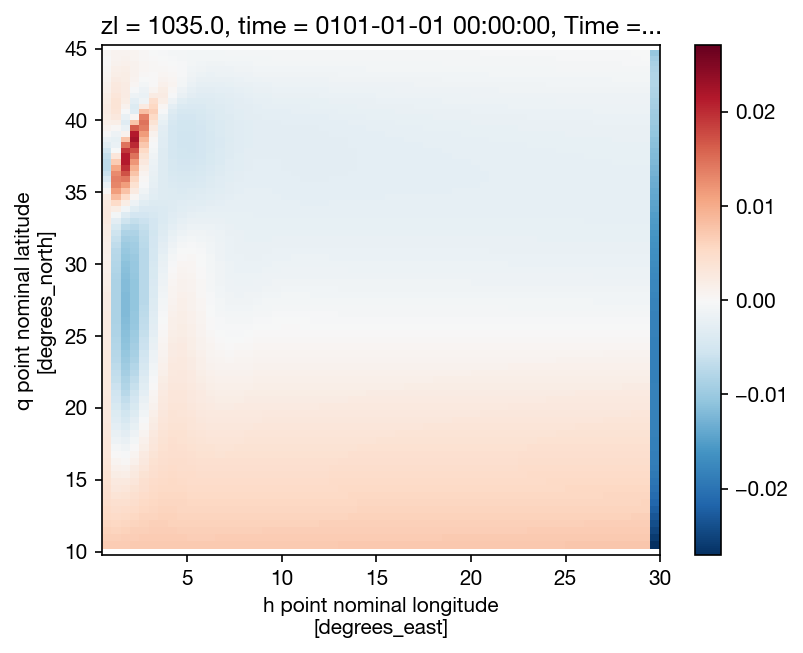

In [150]:
(v-vg).isel(xh=slice(1,None)).plot()

In [155]:
forcing


<xarray.Dataset>
Dimensions:   (xh: 60, xq: 60, yh: 81, yq: 81)
Coordinates:
  * yh        (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * xh        (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq        (yq) float64 10.0 10.49 10.98 11.47 ... 43.61 43.97 44.33 44.68
  * xq        (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 27.5 28.0 28.5 29.0 29.5
Data variables:
    STRESS_X  (yh, xq) float64 -0.15 -0.15 -0.15 -0.15 ... 0.0033 0.0033 0.0033
    STRESS_Y  (yq, xh) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0

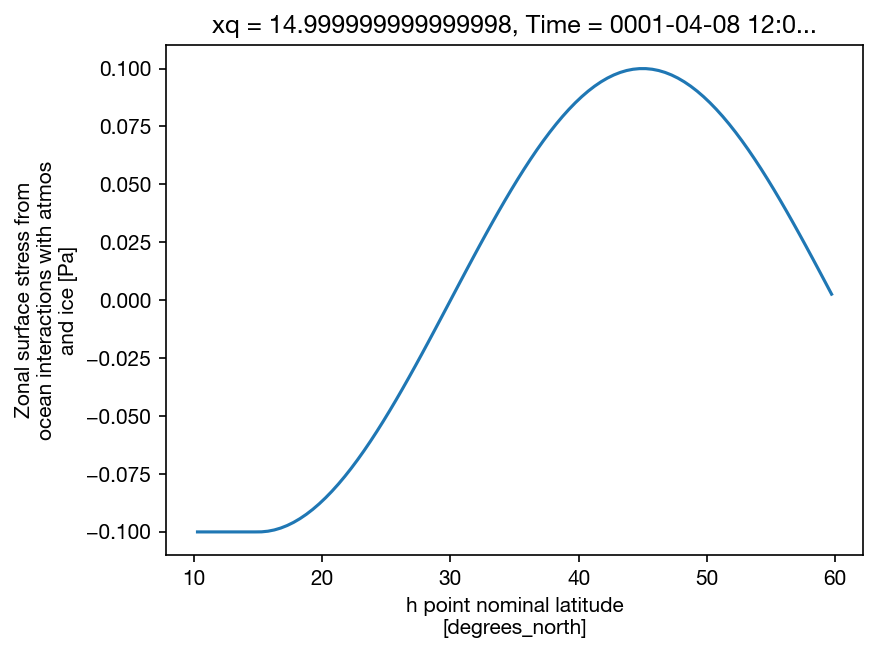

In [33]:
forcing_diag.taux.isel(time=-1,xq=30).plot()

In [40]:
365*2

730

In [75]:
meso = xr.open_dataset('../../MESO_025_23L/INPUT/MESO_str_025.nc')
meso

<xarray.Dataset>
Dimensions:   (lath: 450, latq: 450, lonh: 1440, lonq: 1440)
Coordinates:
  * lath      (lath) float32 -73.99 -73.92 -73.85 ... -0.625 -0.375 -0.125
  * lonq      (lonq) float32 0.0 0.25 0.5 0.75 1.0 ... 359.0 359.2 359.5 359.8
  * latq      (latq) float32 -74.02 -73.95 -73.88 -73.81 ... -0.75 -0.5 -0.25
  * lonh      (lonh) float32 0.125 0.375 0.625 0.875 ... 359.1 359.4 359.6 359.9
Data variables:
    STRESS_X  (lath, lonq) float32 ...
    STRESS_Y  (latq, lonh) float32 ...
Attributes:
    history:  Tue Oct  4 17:22:53 2011: ncrename -v UFLX,STRESS_X -v VFLX,STR...